In [1]:
import numpy as np
import torch
from scipy.io import loadmat
import matplotlib.pyplot as plt

In [2]:
def lle(X, m, tol, n_rule, k=None, epsilon=None):
    N = X.shape[0]
    W = np.zeros((N, N))

    if n_rule == 'knn':
        if k == None:
            raise ValueError('k nearest neighbours not specified!')
        if k >= N:
            raise ValueError('k must be < number of points')
        if k <= 0:
            raise ValueError('k must be a positive number!')
    elif n_rule == 'eps-ball':
        if epsilon == None:
            raise ValueError('epislon not specified!')
        if epsilon <= 0:
            raise ValueError('epsilon must be a positive number!')
    else:
        raise ValueError('n_rule can be either \'knn\' or \'eps-ball\'!')       


    for i in range(N):
        dist = np.sum((X - X[i]) ** 2, axis = 1)

        if n_rule == 'knn':
            closest = np.argsort(dist)[1:k+1]
            ind = np.zeros_like(dist, dtype=bool)
            ind[closest] = True
        else:
            ind = dist < epsilon ** 2
            ind[i] = False

            if not np.any(ind):
                raise ValueError("No neighbors found for this epsilon!")

        Z = X[ind] - X[i]
        C = Z @ Z.T
        ni = C.shape[0]

        C += tol * np.eye(ni)

        ones = np.ones(ni)
        w = np.linalg.solve(C, ones)
        w = w / np.sum(w)
        # --------------------------------------
        W[i,ind] = w

    M = (np.eye(N) - W).T @ (np.eye(N) - W)

    _, eigvecs = np.linalg.eigh(M)

    Y = eigvecs[:, 1:m+1]

    return Y

In [31]:
data = np.load('problem_set1/data/fishbowl_dense.npz')
fishbowl = data['X'].T
fishbowl_reference = data['X'].T[:, 2]

data = np.load('problem_set1/data/swissroll_data.npz')
swissroll = data['x_noisefree'].T
swissroll_reference = data['z'].T[:, 0]

data = np.load('problem_set1/data/flatroll_data.npz')
flatroll = data['Xflat'].T

fishbowl.shape, swissroll.shape, flatroll.shape

((2000, 3), (400, 3), (1000, 2))

In [4]:
def plot_lle_precomputed(X, ref, lle_dict, dataset_name, is_3d=True):
    """
    lle_dict: {k: Y_k}
    ref: color/reference values
    """

    ks = list(lle_dict.keys())
    n = len(ks)

    fig = plt.figure(figsize=(5 * (n + 1), 4))

    # --- original ---
    if is_3d:
        ax = fig.add_subplot(1, n + 1, 1, projection='3d')
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=ref, cmap='viridis')
    else:
        ax = fig.add_subplot(1, n + 1, 1)
        ax.scatter(X[:, 0], X[:, 1], c=ref, cmap='viridis')

    ax.set_title(f"{dataset_name} - original")

    # --- LLE plots ---
    for i, k in enumerate(ks):
        ax = fig.add_subplot(1, n + 1, i + 2)
        Y = lle_dict[k]

        ax.scatter(Y[:, 0], Y[:, 1], c=ref, cmap='viridis')
        ax.set_title(f"LLE k={k}")

    plt.tight_layout()
    plt.show()

In [5]:
import matplotlib.pyplot as plt
import math

def plot_lle_precomputed_grid(X, ref, lle_dict, dataset_name, is_3d=True):
    ks = list(lle_dict.keys())
    n = len(ks)

    cols = 3
    rows = math.ceil((n + 1) / cols)

    fig = plt.figure(figsize=(5 * cols, 4 * rows))

    # --- original plot ---
    ax = fig.add_subplot(rows, cols, 1)

    if is_3d:
        ax = fig.add_subplot(rows, cols, 1, projection='3d')
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=ref, cmap='viridis')
    else:
        ax.scatter(X[:, 0], X[:, 1], c=ref, cmap='viridis')

    ax.set_title(f"{dataset_name} - original")

    # --- LLE plots ---
    for i, k in enumerate(ks):
        ax = fig.add_subplot(rows, cols, i + 2)
        Y = lle_dict[k]

        ax.scatter(Y[:, 0], Y[:, 1], c=ref, cmap='viridis')
        ax.set_title(f"k = {k}")

    plt.tight_layout()
    plt.show()

In [20]:
lle_dict = {k: lle(fishbowl, m=2, tol=1e-3, n_rule='knn', k=k) for k in np.arange(20, 31, 2).tolist() + [25]}

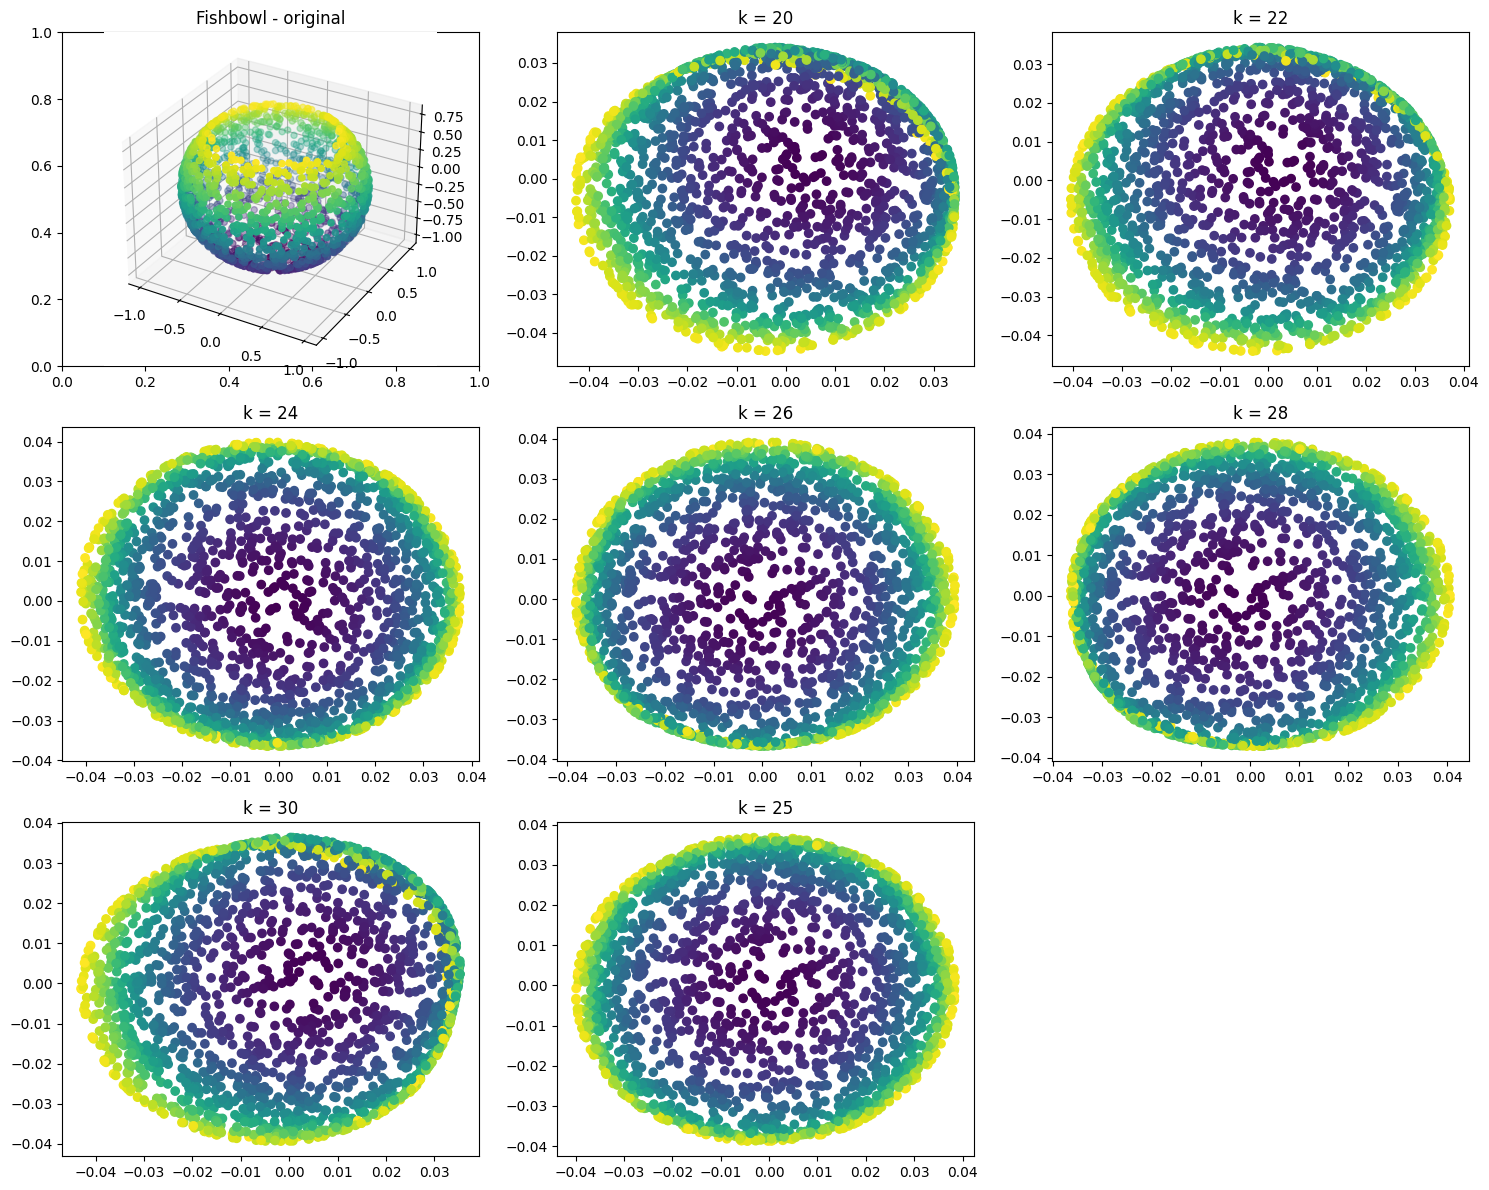

In [23]:
plot_lle_precomputed_grid(fishbowl, fishbowl_reference, lle_dict, "Fishbowl", is_3d=True)

In [42]:
lle_dict_2 = {k: lle(swissroll, m=2, tol=1e-3, n_rule='knn', k=k) for k in np.arange(1, 15)}

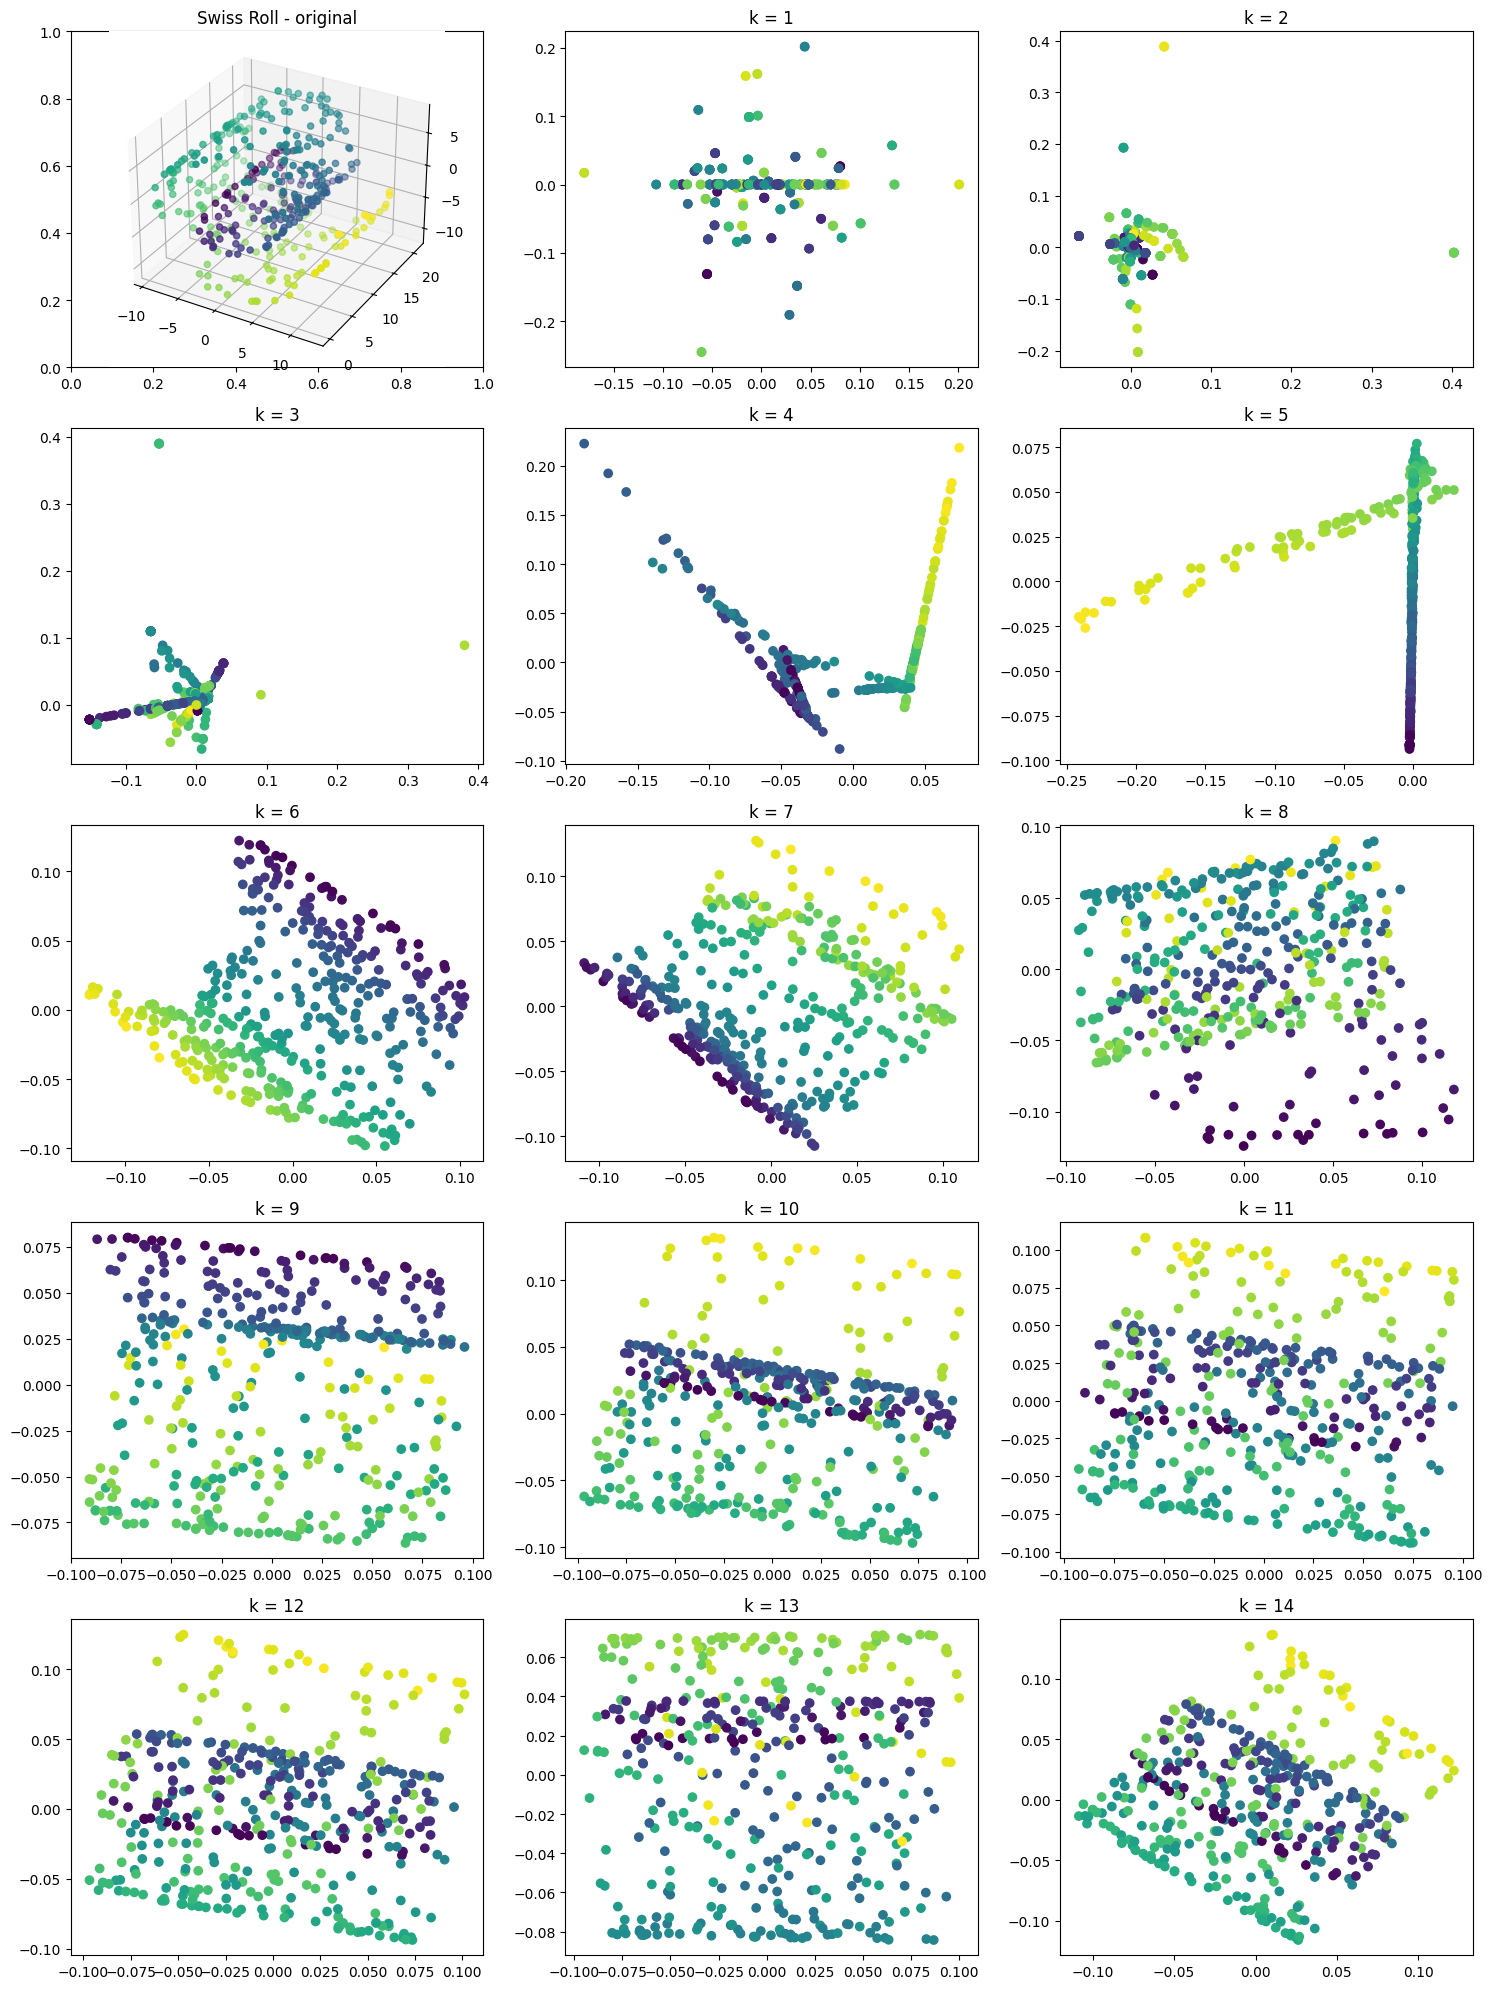

In [43]:
plot_lle_precomputed_grid(swissroll, swissroll_reference, lle_dict_2, "Swiss Roll", is_3d=True)

ValueError: 'c' argument has 2000 elements, which is inconsistent with 'x' and 'y' with size 1000.

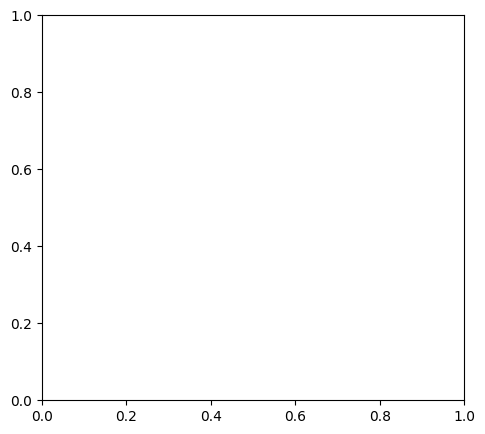

In [18]:
ref = flatroll  # true embedding

fig = plt.figure(figsize=(12, 5))

# --- original 2D ---
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(
    flatroll[:, 0],
    flatroll[:, 1],
    c=ref,
    cmap='viridis'
)
ax1.set_title("Flatroll - original (2D)")

# --- LLE 1D vs reference ---
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(
    flatroll_lle[:, 0],
    ref
)
ax2.set_xlabel("LLE embedding (1D)")
ax2.set_ylabel("Reference")
ax2.set_title("Flatroll - embedding vs reference")

plt.tight_layout()
plt.show()